In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [11]:
df = pd.read_csv("titanic_toy.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [14]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [12]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [13]:
df.shape

(891, 4)

# Applying train-test-split

In [16]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
x_train.shape

(712, 3)

In [23]:
x_test.shape

(179, 3)

In [25]:
x_train.isnull().sum(), x_test.isnull().sum()

(Age       140
 Fare       36
 Family      0
 dtype: int64,
 Age       37
 Fare       9
 Family     0
 dtype: int64)

# Mean and Median imputation with pandas


In [26]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()

mean_fare = df['Fare'].mean()
median_fare = df['Fare'].median()

In [28]:
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)
x_train['Age_median'] = x_train['Age'].fillna(median_age)


x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)
x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)

In [29]:
x_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
753,23.0,7.8958,0,23.000000,23.0,7.8958,7.8958
11,58.0,26.5500,0,58.000000,58.0,26.5500,26.5500
48,NaN,21.6792,2,29.699118,28.0,21.6792,21.6792
61,38.0,80.0000,0,38.000000,38.0,80.0000,80.0000
569,32.0,7.8542,0,32.000000,32.0,7.8542,7.8542


In [30]:
print('Original Age variable variance: ', x_train['Age'].var())
print('Age Variance after median imputation: ', x_train['Age_median'].var())
print('Age Variance after mean imputation: ', x_train['Age_mean'].var())

print('Original Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after median imputation: ', x_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', x_train['Fare_mean'].var())

Original Age variable variance:  210.2517072477435
Age Variance after median imputation:  169.20731007048155
Age Variance after mean imputation:  168.85827839282737
Original Fare variable variance:  2761.0314349486343
Fare Variance after median imputation:  2636.918209408446
Fare Variance after mean imputation:  2621.2351082818004


# KDE plot of Age and Fare comparison with mean and median

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

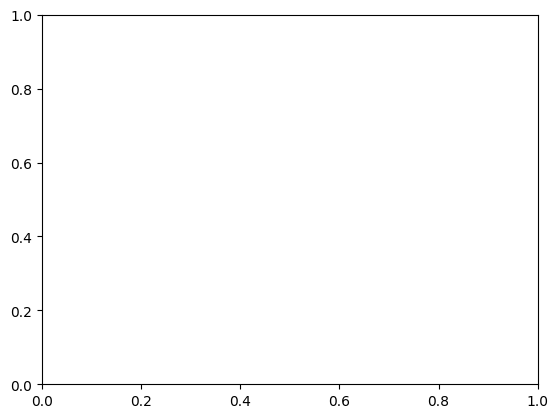

In [68]:
fig = plt.figure()
ax = fig.add_subplot()

# Original Age Distribution 
x_train['Age'].plot(kind='kde',ax=ax)

# Age Mean 
x_train['Age_mean'].plot(kind='kde',ax=ax,color='red')

# Age Median
x_train['Age_median'].plot(kind='kde',ax=ax,color='green')

<Axes: ylabel='Density'>

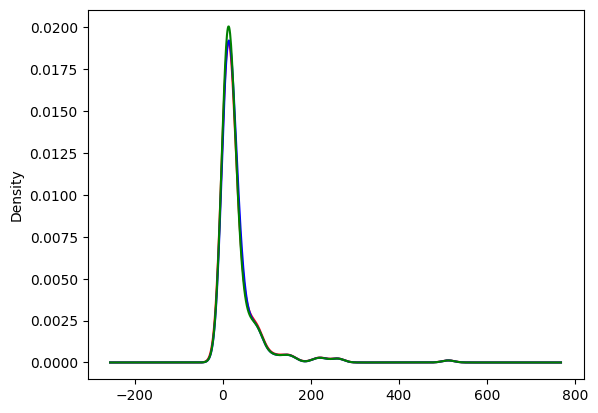

In [40]:
fig = plt.figure()
ax = fig.add_subplot()

# Original Fare variable distribution
x_train['Fare'].plot(kind='kde',ax=ax,color='red')

# fare mean 
x_train['Fare_mean'].plot(kind='kde',ax=ax,color='blue')

# fare median
x_train['Fare_median'].plot(kind='kde',ax=ax,color='green')

In [41]:
x_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.179136,70.085411
Fare,75.481375,2761.031435,18.599163,59.728479,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.620119,-5.587710,17.657625,17.671992
Age_mean,210.251707,59.728479,-5.620119,168.858278,168.804449,56.692642,55.824714
Age_median,210.251707,63.938058,-5.587710,168.804449,169.207310,60.687893,59.731419
Fare_mean,71.179136,2761.031435,17.657625,56.692642,60.687893,2621.235108,2621.439437
Fare_median,70.085411,2761.031435,17.671992,55.824714,59.731419,2621.439437,2636.918209


In [42]:
x_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088924,0.087238
Fare,0.091482,1.000000,0.207193,0.087423,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.257053,-0.255307,0.204983,0.204539
Age_mean,1.000000,0.087423,-0.257053,1.000000,0.998650,0.085214,0.083660
Age_median,1.000000,0.093496,-0.255307,0.998650,1.000000,0.091125,0.089422
Fare_mean,0.088924,1.000000,0.204983,0.085214,0.091125,1.000000,0.997100
Fare_median,0.087238,1.000000,0.204539,0.083660,0.089422,0.997100,1.000000


# Boxplot of age and fare with comarison mean and median

<Axes: >

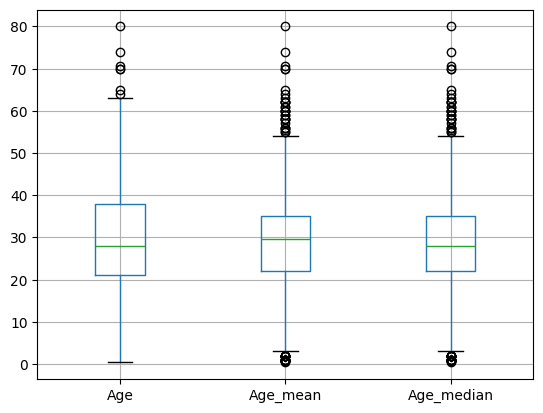

In [43]:
x_train[['Age', 'Age_mean', 'Age_median']].boxplot()

<Axes: >

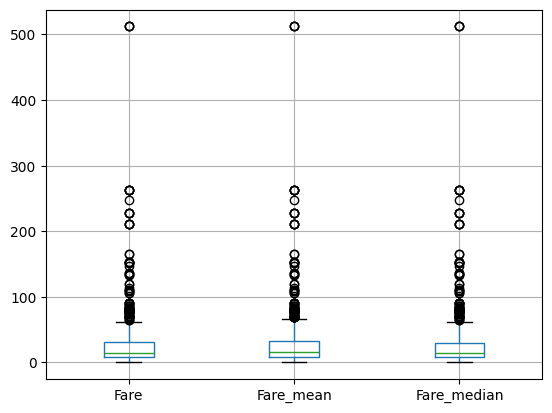

In [45]:
x_train[['Fare','Fare_mean','Fare_median']].boxplot()

# same operation using sklean, columntransformer and SimpleImputer

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
Imputer1 = SimpleImputer(strategy='mean')
Imputer2 = SimpleImputer(strategy='median')

trf = ColumnTransformer([
    ('trf1',Imputer1,['Age']),
    ('trf2',Imputer2,['Age'])
],remainder='passthrough')



In [49]:
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...), ('trf2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [56]:
trf.named_transformers_['trf1'].statistics_

array([29.49884615])

In [57]:
trf.named_transformers_['trf2'].statistics_

array([28.])

In [58]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [59]:
x_train

array([[ 45.5   ,  45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  23.    ,  13.    ,   0.    ],
       [ 32.    ,  32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  41.    ,      nan,   2.    ],
       [ 14.    ,  14.    , 120.    ,   3.    ],
       [ 21.    ,  21.    ,  77.2875,   1.    ]], shape=(712, 4))

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1
